## Analyzing LeTRS Results on simulated data

In [1]:
# Importing libraries
import pandas as pd
import os
import glob
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Loading data

# LeTRS Results
names = "/restricted/projectnb/challenge2025/markerte/sgRNAtor/Elm/LeTRS_Output/sgenerate_simdata_v1/*/results/known_junction.tab"
all_files = glob.glob(names)
print(all_files)

LeTRS_Res = pd.concat(
    (pd.read_csv(f, sep="\t", skipfooter=7).assign(Run = re.search("(?<=sgenerate_simdata_v1/).*(?=/results)", f).group()) for f in all_files), 
    ignore_index=True
)

LeTRS_Res[['c_ct', 'c_f_only', 'c_b_only', 'c_both', 'c_al_one']] = LeTRS_Res["cluster_count"].str.extract('(.+)\\((.+),(.+),(.+),(.+)\\)')


print(LeTRS_Res.head(20))


['/restricted/projectnb/challenge2025/markerte/sgRNAtor/Elm/LeTRS_Output/sgenerate_simdata_v1/final_COV_S_+_ORF7a_Dominant_rep2_agregate/results/known_junction.tab', '/restricted/projectnb/challenge2025/markerte/sgRNAtor/Elm/LeTRS_Output/sgenerate_simdata_v1/final_COV_Reverse_Decay_rep3_agregate/results/known_junction.tab', '/restricted/projectnb/challenge2025/markerte/sgRNAtor/Elm/LeTRS_Output/sgenerate_simdata_v1/final_COV_M_+_ORF8_Dominant_rep2_agregate/results/known_junction.tab', '/restricted/projectnb/challenge2025/markerte/sgRNAtor/Elm/LeTRS_Output/sgenerate_simdata_v1/final_COV_M_+_ORF8_Dominant_rep1_agregate/results/known_junction.tab', '/restricted/projectnb/challenge2025/markerte/sgRNAtor/Elm/LeTRS_Output/sgenerate_simdata_v1/final_COV_Exponential_Decay_rep1_agregate/results/known_junction.tab', '/restricted/projectnb/challenge2025/markerte/sgRNAtor/Elm/LeTRS_Output/sgenerate_simdata_v1/final_COV_Sparse_1_rep2_agregate/results/known_junction.tab', '/restricted/projectnb/chal

/scratch/418441.1.ood/ipykernel_841228/3106937991.py:9: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  (pd.read_csv(f, sep="\t", skipfooter=7).assign(Run = re.search("(?<=sgenerate_simdata_v1/).*(?=/results)", f).group()) for f in all_files),
/scratch/418441.1.ood/ipykernel_841228/3106937991.py:9: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  (pd.read_csv(f, sep="\t", skipfooter=7).assign(Run = re.search("(?<=sgenerate_simdata_v1/).*(?=/results)", f).group()) for f in all_files),
/scratch/418441.1.ood/ipykernel_841228/3106937991.py:9: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  (pd.read_csv(f, sep="\t", skipfooter=7).assign(Run = re.search(

In [3]:
# sgENERATE "ground truth"

sgen_GT_dict = {"Run": [], "subgenome": [], "sgen_count": []}

for run in LeTRS_Res['Run'].unique():
    f = open(f"/restricted/projectnb/challenge2025/Data/sgenerate_simdata_v1/{run[:-8]}proportion.txt", "r")
    for l in f.readlines():
        sgen_GT_dict["Run"].append(run)
        sgen_GT_dict["subgenome"].append(l.split()[0])
        sgen_GT_dict["sgen_count"].append(l.split()[1])

sgen_gt = pd.DataFrame(sgen_GT_dict)

print(sgen_gt.head())

sgen_gt.to_csv("sgen_groundtruth_ORFs.csv", index = False)

                                          Run subgenome sgen_count
0  final_COV_S_+_ORF7a_Dominant_rep2_agregate         S       1249
1  final_COV_S_+_ORF7a_Dominant_rep2_agregate     ORF3a        208
2  final_COV_S_+_ORF7a_Dominant_rep2_agregate         E        208
3  final_COV_S_+_ORF7a_Dominant_rep2_agregate         M        208
4  final_COV_S_+_ORF7a_Dominant_rep2_agregate      ORF6        208


In [29]:
merged = pd.merge(sgen_gt, LeTRS_Res, on=["Run", "subgenome"],how = "inner")

merged["Run"] = merged["Run"].str[10:].str[:-9]

merged["prop_diff"] = merged["c_ct"].astype(int)/merged["sgen_count"].astype(int)

melted = pd.melt(merged, id_vars = ["Run", "subgenome"], value_vars = ["sgen_count", "c_ct"], value_name = "count", var_name = "sim")

melted["count"] = melted["count"].astype(int)

mapping = {"sgen_count": "Ground Truth", "c_ct": "LeTRS"}

melted["sim"] = melted["sim"].map(mapping)


merged.head()

print(merged["subgenome"].unique())

<StringArray>
['S', 'ORF3a', 'E', 'M', 'ORF6', 'ORF7a', 'ORF8', 'N', 'ORF10']
Length: 9, dtype: str


/restricted/projectnb/challenge2025/markerte/sgRNAtor/Elm/LeTRS_Analysis/env/lib/python3.14/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


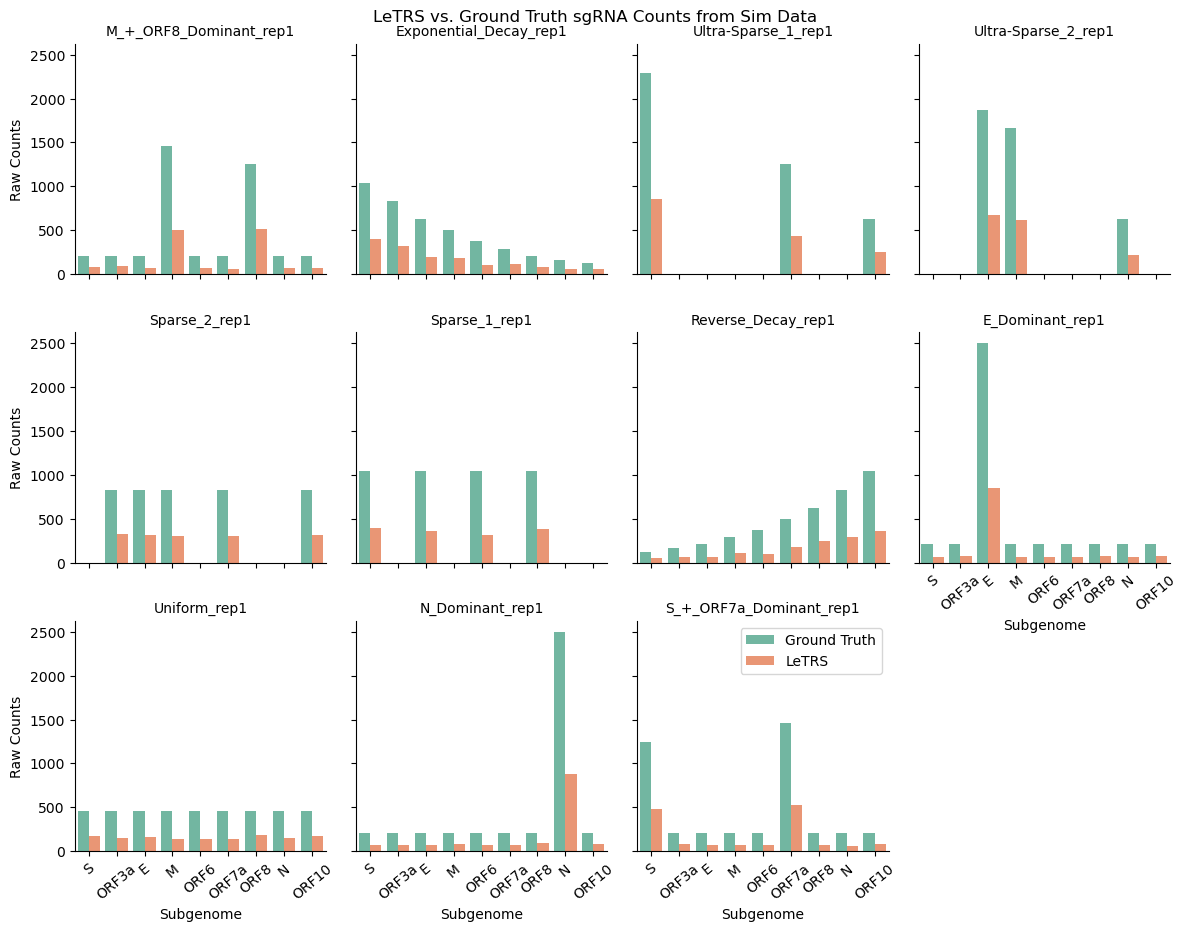

In [27]:
grid = sns.FacetGrid(melted[~melted["Run"].str.contains("rep[23]")], col="Run", col_wrap=4)
grid.map(sns.barplot, "subgenome", "count", data = melted, hue = "sim", palette = "Set2")
grid.set_titles("{col_name}")
grid.set_xlabels("Subgenome")
grid.set_xticklabels(["S", "ORF3a", "E", "M", "ORF6", "ORF7a", "ORF8", "N", "ORF10"], rotation=40)
grid.set_ylabels("Raw Counts")
plt.suptitle("LeTRS vs. Ground Truth sgRNA Counts from Sim Data", y=1)
plt.legend()
plt.show()

/restricted/projectnb/challenge2025/markerte/sgRNAtor/Elm/LeTRS_Analysis/env/lib/python3.14/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


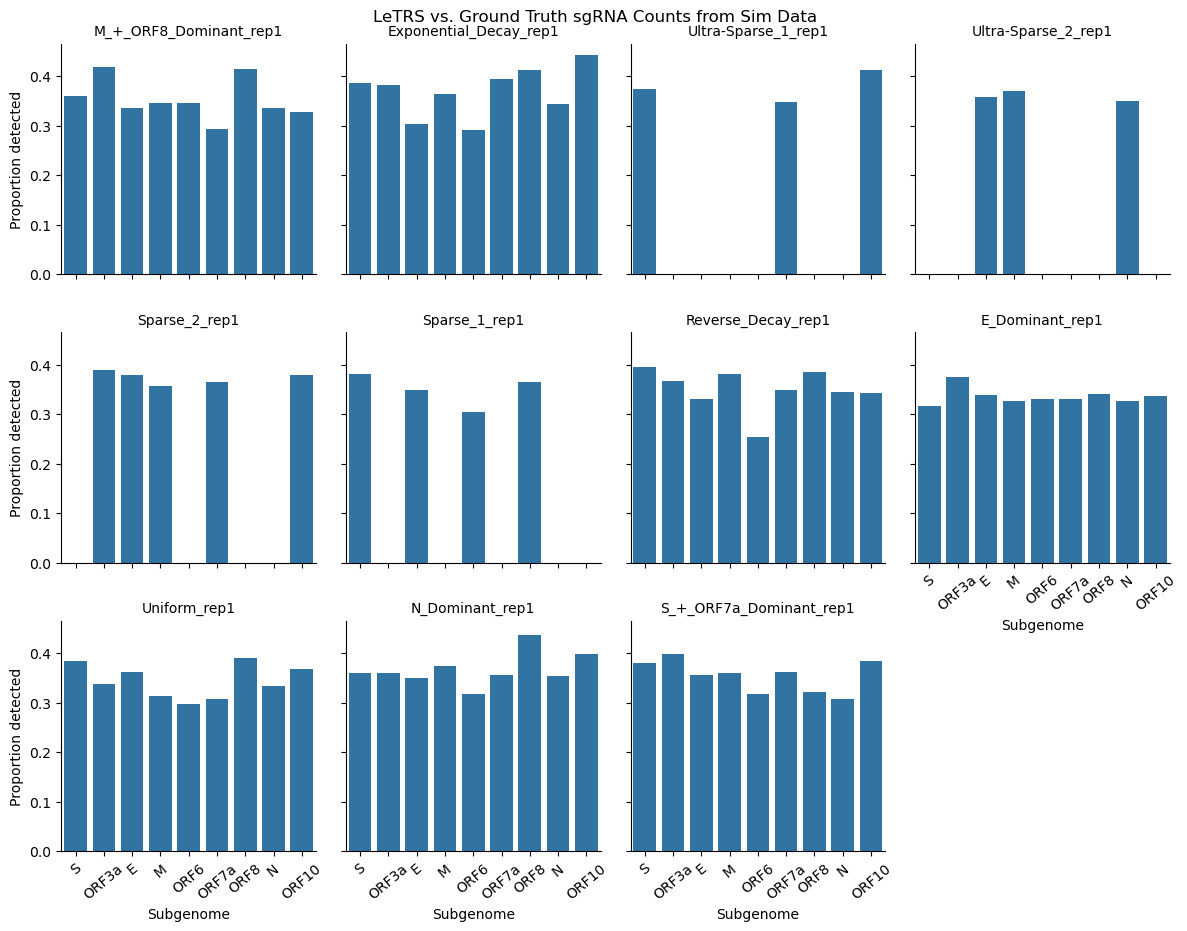

In [30]:
grid = sns.FacetGrid(merged[~merged["Run"].str.contains("rep[23]")], col="Run", col_wrap=4)
grid.map(sns.barplot, "subgenome", "prop_diff", data = merged)
grid.set_titles("{col_name}")
grid.set_xlabels("Subgenome")
grid.set_xticklabels(["S", "ORF3a", "E", "M", "ORF6", "ORF7a", "ORF8", "N", "ORF10"], rotation=40)
grid.set_ylabels("Proportion detected")
plt.suptitle("LeTRS vs. Ground Truth sgRNA Counts from Sim Data", y=1)
#plt.legend()
plt.show()